# AUTOBULL Darts Counting System 

The goal of this project is to develop an automatic, real-time darts scoring system using three AI-assisted cameras, a lighting system, and a Raspberry Pi. The system is mounted around the rim of a dartboard ("Dartscheibe") and uses machine learning and computer vision to detect and analyze where darts land. The purpose is to eliminate manual scoring, enhance accuracy, and provide instant visual feedback for players. The solution is compact, intelligent, and ideal for both casual players and competitive environments.

We recorded 1 second videos of the shots, triggered by motion detection (folder DataAquisition). The shots are structered into different sets, with always 3 shots in 3 different camera angles. This method was chosen, so that we could calculate the score for 3 shots and not only one dart. Then the last frame of the videos was extracted for further processing.

As a first step, we needed boudning boxes to get the location of the darts, which can be seen in the Preprocessing folder. Object detection was done first using the labelImg tool for manual drawing of bounding boxes. Then a simple model was trained and used for semi-automatic drawing of the boxes, the biggest problems for the model were darts right in front of the camera or tilted darts. The boxes were saved in a YOLO-readable format. 

At first we wanted to also incoporate the seperation in singles, doubles and triples for each point zone. The problem here was, that these were not scored often enough, since we are not good enough darts players. The model for this is saved as AutoBullMain_old and has a zone accurcy of 78,91%, but only a score accuracy of 3,12%.

This script shows the creation of the points labelling model.

In [31]:
# Import necessary libraries
import os
import cv2
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torchvision.models as models
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import copy
from sklearn.preprocessing import LabelEncoder
from random import shuffle
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score

### Load the data of the first dart of every set

In [ ]:
# File paths
# Invalid IDs are the ones where the darts was not shown alone, eg. with a hand, ...
IMG_DIR = '../Data/snapshots'
LABELS_DIR = '../Data/bbox_labels'
POINTS_CSV = '../Data/points/points_labels.csv'
INVALID_IDS = ['set_024', 'set_144','set_145', 'set_172', 'set_213']

In [ ]:
# ----------------------------
# Load CSV with dart score data, excluding invalid set IDs
# converts the DataFrame into a dictionary, uses the 'set_id' column as the key, 
# and each value is a dictionary containing the rest of the row's data 
# ----------------------------
def load_points_csv(csv_path, invalid_set_ids=None):
    df = pd.read_csv(csv_path, encoding='latin1')  # Load CSV with score data
    if invalid_set_ids:
        # Remove rows with invalid set IDs (bad/missing data)
        df = df[~df['set_id'].isin(invalid_set_ids)].reset_index(drop=True)
    
    # Convert to dictionary for fast lookup: {set_id: {score, pfeil1, ...}}
    score_lookup = df.set_index("set_id").to_dict(orient="index")
    return df, score_lookup

# ----------------------------
# Load an image from file
# ----------------------------
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"[Warning] Image not found: {image_path}")
    return image

# ----------------------------
# Load bounding boxes from YOLO format label file
# coordinates of the boxes are saved a dictionary with keys "class_id", "cx", "cy", "w", and "h", 
# ----------------------------
def load_yolo_bboxes(label_path):
    bboxes = []
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    # Parse YOLO format: class_id cx cy w h
                    class_id, cx, cy, w, h = map(float, parts[:5])
                    bboxes.append({
                        "class_id": int(class_id),
                        "cx": cx,
                        "cy": cy,
                        "w": w,
                        "h": h
                    })
    else:
        print(f"[Warning] Label file not found: {label_path}")
    return bboxes

# ----------------------------
# Load 3 images + labels for first dart throw (cam 0, 2, 4)
# function constructs file patterns to locate the relevant image and label files using the os.path.join
# and formatted strings
# glob.glob to find all files matching these patterns and sorts the results to ensure consistent ordering
# ----------------------------
def load_first_dart_multicam(set_id, image_dir, label_dir, cams=[0, 2, 4]):
    images = []
    labels = []
    
    for cam in cams:
        # Find image and label files matching pattern
        image_pattern = os.path.join(image_dir, f"{set_id}_pfeil1_cam{cam}_*.jpg")
        label_pattern = os.path.join(label_dir, f"{set_id}_pfeil1_cam{cam}_*.txt")
        
        image_files = sorted(glob.glob(image_pattern))
        label_files = sorted(glob.glob(label_pattern))
        
        if not image_files:
            print(f"[Warning] No image found for {set_id} cam{cam}")
            continue
        
        image_path = image_files[0]  # Use first image found
        label_path = label_files[0] if label_files else None  # Use first label if exists
        
        image = load_image(image_path)
        bboxes = load_yolo_bboxes(label_path) if label_path else []

        images.append(image)     # RGB image
        labels.append(bboxes)    # List of bbox dicts

    return images, labels  # Each list has length 3 (cams 0, 2, 4)

# ----------------------------
# Load full dataset for the first dart across all sets
# ----------------------------
def load_dataset_first_dart(csv_path, image_dir, label_dir, invalid_set_ids=None):
    df, score_lookup = load_points_csv(csv_path, invalid_set_ids)
    dataset = []

    for _, row in df.iterrows():
        set_id = row["set_id"]

        # Load images and bboxes for each cam view
        images, labels = load_first_dart_multicam(set_id, image_dir, label_dir)

        if len(images) < 3:
            print(f"[Warning] Incomplete camera views for {set_id}")
            continue  # Skip incomplete sets

        # Build sample entry
        sample = {
            "set_id": set_id,
            "images": images,   # List of 3 images (1 per camera)
            "bboxes": labels,   # List of 3 bbox lists (per camera)
            "points_info": {
                "points": row.get("pfeil1"),         # Score for first dart
                "score": row.get("total_score"),     # Total score of the set (optional)
            }
        }
        dataset.append(sample)
    
    return dataset  # List of samples, each with image + bbox + score

In [4]:
# Load the dataset
data = load_dataset_first_dart(POINTS_CSV, IMG_DIR, LABELS_DIR, invalid_set_ids=INVALID_IDS)
print("Dataset loaded successfully with", len(data), "samples.")


Dataset loaded successfully with 215 samples.


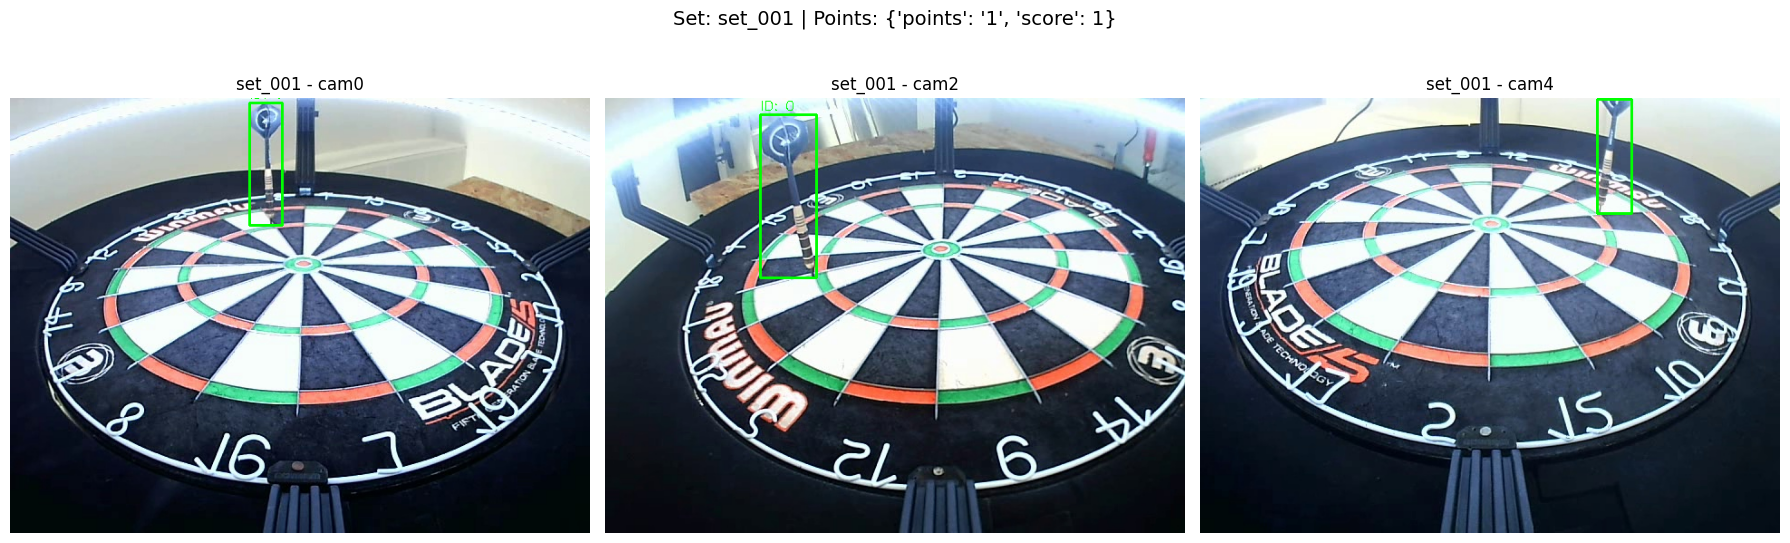

In [ ]:

# Visualization of a sample with bounding boxes
def draw_bboxes(image, bboxes, box_color=(0, 255, 0), label_font=cv2.FONT_HERSHEY_SIMPLEX):
    """Draw YOLO-format bounding boxes on a copy of the image."""
    img_h, img_w = image.shape[:2]
    img = image.copy()

    for bbox in bboxes:
        # Convert YOLO format to pixel coordinates
        cx, cy, w, h = bbox['cx'], bbox['cy'], bbox['w'], bbox['h']
        x1 = int((cx - w / 2) * img_w)
        y1 = int((cy - h / 2) * img_h)
        x2 = int((cx + w / 2) * img_w)
        y2 = int((cy + h / 2) * img_h)

        class_id = bbox.get('class_id', 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), box_color, 2)
        cv2.putText(img, f'ID: {class_id}', (x1, y1 - 5), label_font, 0.5, box_color, 1)

    return img

# Display the 3 camera images with bounding boxes and point info
def visualize_sample(sample):
    images = sample['images']
    bboxes = sample['bboxes']
    points_info = sample['points_info']
    set_id = sample['set_id']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cam_labels = ['cam0', 'cam2', 'cam4']

    for i in range(3):
        img_with_boxes = draw_bboxes(images[i], bboxes[i])
        img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].axis("off")
        axes[i].set_title(f"{set_id} - {cam_labels[i]}")

    # Show point info 
    plt.suptitle(f"Set: {set_id} | Points: {points_info}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize the first sample

visualize_sample(data[0])

### Use a CNN Model without Data Augmentation

In [ ]:
# The DartDataset class is a custom PyTorch dataset designed to handle dart scoring data

class DartDataset(Dataset):

    #Args of __init__:
        # data: List of samples (from load_dataset_first_dart)
        # label_encoder: sklearn LabelEncoder to convert labels to int
        # image_size: size for image resizing
        # max_boxes: max number of bounding boxes per image
        # use_bboxes: whether to return bbox info or not
    # Image preprocessing: convert OpenCV image to Tensor

    def __init__(self, data, label_encoder, image_size=(224, 224), max_boxes=3, use_bboxes=False):

        self.data = data
        self.label_encoder = label_encoder
        self.use_bboxes = use_bboxes
        self.max_boxes = max_boxes
        
        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize(image_size),
            T.ToTensor(),
        ])

    # Returns the number of samples in the dataset
    def __len__(self):
        return len(self.data)


    # Convert YOLO-style bbox dicts to a tensor of shape [3, max_boxes, 5]
    # Each bbox: [class_id, cx, cy, w, h]
    # If fewer than max_boxes, pad with zeros.
    def encode_bboxes(self, bboxes_list):
        out = torch.zeros((3, self.max_boxes, 5))  # cams x boxes x features

        for i, bboxes in enumerate(bboxes_list):  # for each camera
            for j, bbox in enumerate(bboxes[:self.max_boxes]):
                out[i, j] = torch.tensor([
                    bbox['class_id'],
                    bbox['cx'],
                    bbox['cy'],
                    bbox['w'],
                    bbox['h']
                ])
        return out


    # method retrieves a single sample, loads and transforms the three camera images, stacks them into a tensor, 
    # and encodes the class label 
    # method works with or without bounding box features
    def __getitem__(self, idx):
        sample = self.data[idx]

        imgs = [self.transform(img) for img in sample['images']]  # list of 3
        imgs_tensor = torch.stack(imgs)  # shape: [3, C, H, W]
        label_str = sample['points_info']['points']  # e.g. "20", "MISS"
        target = torch.tensor(self.label_encoder.transform([label_str])[0], dtype=torch.long)

        if self.use_bboxes:
            bboxes_tensor = self.encode_bboxes(sample['bboxes'])  # shape: [3, max_boxes, 5]
            return imgs_tensor, bboxes_tensor, target
        else:
            return imgs_tensor, target


In [ ]:
# Clean the dataset by normalizing the 'points' field in each sample
# skipping samples where 'points' is NaN or None
# Normalize: ensure uppercase string (e.g. "20", "MISS", "BULL")

clean_data = []

for sample in data:
    points = sample['points_info'].get('points')
    if pd.isna(points):
        continue

    sample['points_info']['points'] = str(points).strip().upper()

    clean_data.append(sample)

# Replace old data with cleaned version
data = clean_data

In [ ]:
# Convert all labels to strings for consistency
all_labels = [str(sample["points_info"]["points"]).upper() for sample in data]

# Optional: validate unique set
unique_labels = sorted(set(all_labels))
print("Detected classes:", unique_labels)

# Encode labels to integers
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
num_classes = len(label_encoder.classes_)

Detected classes: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9', 'BULL', 'MISS']


In [ ]:
# Create the DartDataset instance
# split the dataset into training and validation sets
dataset = DartDataset(data,label_encoder, use_bboxes=True)
train_size = int(0.8 * len(dataset)) 
val_size = len(dataset) - train_size 
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

In [ ]:
# A simple CNN model for dart scoring using ResNet18 features.
# It can  use bounding box  information from multiple camera views.

class DartScoreModel(nn.Module):

    def __init__(self, num_classes, max_boxes=3, use_bboxes=True):
        super().__init__()
        self.use_bboxes = use_bboxes
        self.max_boxes = max_boxes

        # CNN for image features 
        # ResNet18 architecture as a feature extractor, allowing it to process images and 
        # output a 512-dimensional feature vector for each
        base_model = models.resnet18(weights=None)
        base_model.fc = nn.Identity()
        self.feature_extractor = base_model  

        # Bounding box encoder: MLP
        # flattens the bounding box tensor and projects it down to a 64-dimensional vector
        # -> enables the model to incorporate spatial information 
        self.bbox_encoder = nn.Sequential(
            nn.Flatten(),  # [3, max_boxes, 5] -> flat vector
            nn.Linear(3 * max_boxes * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        # Final classification head outputs logits for each class
        self.head = nn.Sequential(
            nn.Linear(3 * 512 + 64, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    # input images are reshaped and together with bounding boxes concatenated for all camera views
    # converted to final output logits for further classification tasks
    def forward(self, x, bboxes):  # x: [B, 3, C, H, W], bboxes: [B, 3, max_boxes, 5]
        B = x.size(0)
        x = x.view(B * 3, *x.shape[2:])  # [B*3, C, H, W]
        feats = self.feature_extractor(x)  # [B*3, 512]
        feats = feats.view(B, -1)  # [B, 3*512]

        if self.use_bboxes:
            bbox_feats = self.bbox_encoder(bboxes)  # [B, 64]
            combined = torch.cat([feats, bbox_feats], dim=1)  # [B, 3*512 + 64]
        else:
            combined = feats  # no bbox features

        logits = self.head(combined)
        return logits

In [ ]:
# Initialize the model, optimizer, and loss function
# if available GPU, use it for training
# Adam is used as optimizer which automatically adjusts the learning rate during training
# loss function is set to cross-entropy loss, which is standard for multi-class classification problems
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DartScoreModel(num_classes=num_classes, max_boxes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Train the model
# model runs through 20 epochs
for epoch in range(1, 21):
    model.train()
    total_loss = 0

    for x, bboxes, y in train_loader:
        x, bboxes, y = x.to(device), bboxes.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x, bboxes)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f}")

Epoch 1 | Train Loss: 3.1482
Epoch 2 | Train Loss: 2.9113
Epoch 3 | Train Loss: 2.7723
Epoch 4 | Train Loss: 2.6907
Epoch 5 | Train Loss: 2.4687
Epoch 6 | Train Loss: 2.3661
Epoch 7 | Train Loss: 2.1261
Epoch 8 | Train Loss: 1.8470
Epoch 9 | Train Loss: 1.6537
Epoch 10 | Train Loss: 1.3459
Epoch 11 | Train Loss: 1.0470
Epoch 12 | Train Loss: 0.7739
Epoch 13 | Train Loss: 0.5572
Epoch 14 | Train Loss: 0.3694
Epoch 15 | Train Loss: 0.2474
Epoch 16 | Train Loss: 0.1823
Epoch 17 | Train Loss: 0.1902
Epoch 18 | Train Loss: 0.1877
Epoch 19 | Train Loss: 0.1260
Epoch 20 | Train Loss: 0.0824


In [ ]:
# evaluate the model on the validation set and return predictions and targets."""
# model is set to evaluation mode

def evaluate_model(model, val_loader, label_encoder, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    # Ensure no gradients are computed during evaluation
    # This saves memory and speeds up the process
    with torch.no_grad():
        for x, bboxes, y in val_loader:
            x, bboxes, y = x.to(device), bboxes.to(device), y.to(device)
            logits = model(x, bboxes)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    # Calculate accuracy
    acc = correct / total
    print(f"\nValidation Accuracy: {acc:.2%}")
    return all_preds, all_targets

In [ ]:
# perform evaluation on the validation set
all_preds, all_targets = evaluate_model(model, val_loader, label_encoder, device)
 


Validation Accuracy: 16.28%


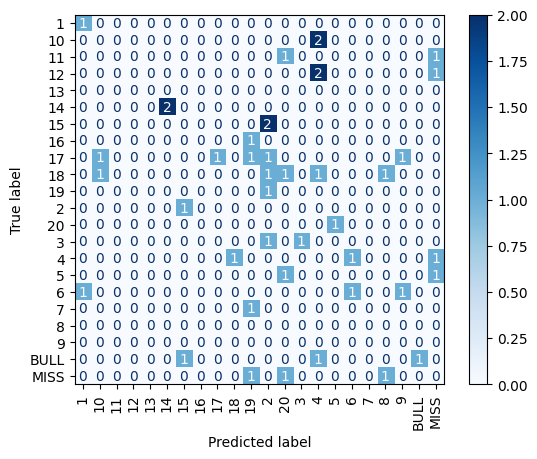

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=range(len(label_encoder.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues')

The bad accurazy of the CNN shows that the Data set is too small and data augmentation is needed.

### Basic Data Augmentation

In [ ]:
# Add Gaussian noise to the input tensor
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std

# Return a transform for training images with augmentations
# converts images to PIL format, resizes them, applies random color jitter (adjusting brightness, contrast, and saturation), 
# and applies a Gaussian blur with random intensity, applies the AddGaussianNoise transformation
def get_train_transform(image_size=(224, 224)):
    return T.Compose([
        T.ToPILImage(),
        T.Resize(image_size),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
        T.ToTensor(),
        AddGaussianNoise(std=0.01),
    ])

In [ ]:
# Applies transform to a sample's images, returns a new sample with images as NumPy arrays
# copies the original sample to avoid modifying it directly
# iterates over each image in the sample, applies the transformation, and converts the resulting tensor
def augment_sample(sample, transform):
    new_sample = copy.deepcopy(sample)
    new_images = []

    for img in sample['images']:
        img_tensor = transform(img)  # apply transform (returns tensor)
        img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        new_images.append(img_np)

    new_sample['images'] = new_images
    return new_sample

In [ ]:
# Split original data
train_size = int(0.8 * len(data))
val_size = len(data) - train_size
train_data, val_data = random_split(data, [train_size, val_size])

# Convert Subset to list
train_data = [train_data[i] for i in range(len(train_data))]

# Apply augmentation N times per sample
# first adds the original sample to the augmented list, then applies the transformation N times
# to create augmented versions of each sample
def augment_dataset(data, transform, num_augments=2):
    augmented = []
    for sample in data:
        augmented.append(sample)  # original
        for _ in range(num_augments):
            augmented.append(augment_sample(sample, transform))
    return augmented

# applies augmentation 2 times per sample and shuffles the resulting dataset
augmented_train_data = augment_dataset(train_data, get_train_transform(), num_augments=2)
shuffle(augmented_train_data)

In [ ]:
# Convert augmented data to DartDataset
# use_bboxes=True to include bounding boxes in the dataset
train_ds = DartDataset(augmented_train_data, label_encoder, use_bboxes=True)
val_ds = DartDataset(val_data, label_encoder, use_bboxes=True)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

In [ ]:
# Define the Model for augmented data
class DartAugmentedModel(nn.Module):
    def __init__(self, num_classes, max_boxes=3):
        super().__init__()
        self.max_boxes = max_boxes

        # Image feature extractor uses a ResNet18 architecture 
        base_model = models.resnet18(weights=None)
        base_model.fc = nn.Identity()
        self.feature_extractor = base_model  

        # Bounding box encoder
        # bounding boxes for all cameras are flattened into a single vector, passed through two linear layers 
        # with ReLU activations, and reduced to a 64-dimensional feature vector
        # -> allows the model to incorporate spatial information about the dart locations
        self.bbox_encoder = nn.Sequential(
            nn.Flatten(),  # → [B, 3 * max_boxes * 5]
            nn.Linear(3 * max_boxes * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Final classifier
        # to produce the final class logits, one for each possible dart score
        self.head = nn.Sequential(
            nn.Linear(3 * 512 + 64, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, bboxes):  
        B = x.size(0)

        # Extract image features
        x = x.view(B * 3, *x.shape[2:])              
        img_feats = self.feature_extractor(x)  
        img_feats = img_feats.view(B, 3 * 512)      

        # Encode bounding boxes
        bbox_feats = self.bbox_encoder(bboxes)      

        # Concatenate image + bbox features
        combined = torch.cat([img_feats, bbox_feats], dim=1)  
        logits = self.head(combined)               

        return logits

In [ ]:
# Initialize the model, optimizer, and loss function as before
model = DartAugmentedModel(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Train the model on augmented data
for epoch in range(30):
    model.train()
    total_loss = 0

    for x, bboxes, y in train_loader:
        x, bboxes, y = x.to(device), bboxes.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x, bboxes)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f}")


Epoch 0 | Train Loss: 3.0543
Epoch 1 | Train Loss: 2.9072
Epoch 2 | Train Loss: 2.7602
Epoch 3 | Train Loss: 2.4605
Epoch 4 | Train Loss: 1.9988
Epoch 5 | Train Loss: 1.4674
Epoch 6 | Train Loss: 0.8990
Epoch 7 | Train Loss: 0.5523
Epoch 8 | Train Loss: 0.2967
Epoch 9 | Train Loss: 0.1345
Epoch 10 | Train Loss: 0.0695
Epoch 11 | Train Loss: 0.0306
Epoch 12 | Train Loss: 0.0221
Epoch 13 | Train Loss: 0.0147
Epoch 14 | Train Loss: 0.0096
Epoch 15 | Train Loss: 0.0074
Epoch 16 | Train Loss: 0.0058
Epoch 17 | Train Loss: 0.0051
Epoch 18 | Train Loss: 0.0043
Epoch 19 | Train Loss: 0.0035
Epoch 20 | Train Loss: 0.0034
Epoch 21 | Train Loss: 0.0033
Epoch 22 | Train Loss: 0.0024
Epoch 23 | Train Loss: 0.0022
Epoch 24 | Train Loss: 0.0019
Epoch 25 | Train Loss: 0.0017
Epoch 26 | Train Loss: 0.0019
Epoch 27 | Train Loss: 0.0039
Epoch 28 | Train Loss: 0.8862
Epoch 29 | Train Loss: 0.8688


In [ ]:
# Evaluate the model on the validation set
all_preds, all_targets = evaluate_model(model, val_loader, label_encoder, device)


Validation Accuracy: 16.28%


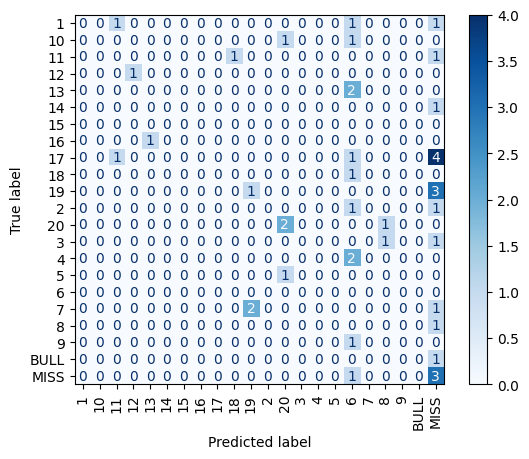

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=range(len(label_encoder.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues')

The Model shows overfitting in the trainingprocess.
This can be seen as the train Loss increases to the end.

In [ ]:

# Plot a histogram of class label distribution in the dataset
def plot_label_histogram(dataset, label_encoder=None, title="Class Distribution"):
    """   Plot a histogram of class label distribution in the dataset."""
    # Collect all labels
    labels = []
    for _, _, label in dataset:
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)

    # Count occurrences
    label_counts = Counter(labels)

    # Sort by label index
    keys = sorted(label_counts.keys())
    counts = [label_counts[k] for k in keys]

    # Use label names if label_encoder is available
    if label_encoder:
        class_names = label_encoder.inverse_transform(keys)
    else:
        class_names = [str(k) for k in keys]

    # Plot
    plt.figure(figsize=(12, 5))
    plt.bar(class_names, counts)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

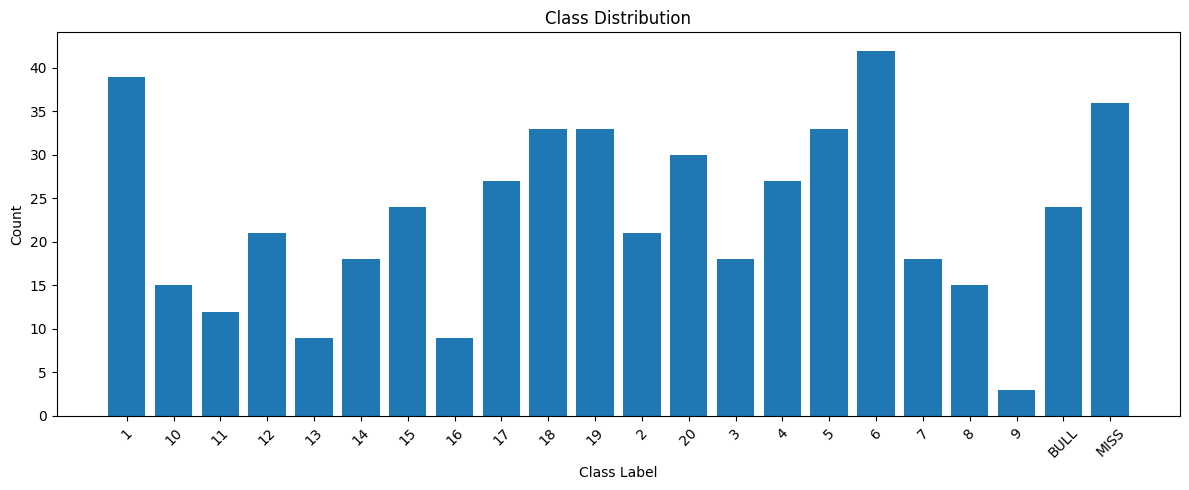

In [ ]:
# plot histogram of class distribution for the training dataset
plot_label_histogram(train_ds, label_encoder)

As can be seen in the histogram, the training data is unbalanced. Therefore Models.ResNet18_weights is used to counter this imbalance.

In [ ]:
# Define the improved Dart scoring model
# Models.ResNet18_weights are used for better performance
class DartScoringModelImproved(nn.Module):
    def __init__(self, num_classes: int, max_boxes: int = 3):
        super().__init__()

        # ResNet18 pretrained feature extractor
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        resnet.fc = nn.Identity()
        self.feature_extractor = resnet  

        # Bounding box encoder
        self.bbox_encoder = nn.Sequential(
            nn.Linear(3 * max_boxes * 5, 128),  
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, bboxes):  
        B = x.size(0)
        img_features = []

        for i in range(3):
            feat = self.feature_extractor(x[:, i])  
            img_features.append(feat)

        img_features = torch.cat(img_features, dim=1)  
        bbox_flat = bboxes.view(B, -1)                 
        bbox_feat = self.bbox_encoder(bbox_flat)      

        combined = torch.cat([img_features, bbox_feat], dim=1) 
        return self.classifier(combined)

In [ ]:
# load the dataset with bounding boxes
train_ds_improved = DartDataset(augmented_train_data, label_encoder, use_bboxes=True)
val_ds_improved = DartDataset(val_data, label_encoder,use_bboxes=True)

train_loader_improved = DataLoader(train_ds_improved, batch_size=8, shuffle=True)
val_loader_improved = DataLoader(val_ds_improved, batch_size=8)

In [ ]:
# calculates class weights to address class imbalance in the training dataset

# Get all labels from dataset and ensure they are integers
all_labels = []
for _, _, label in train_ds_improved:
    all_labels.append(label.item())  

# Get unique classes actually used in dataset
used_classes = np.unique(all_labels)

# Get all possible class indices from label encoder
all_class_indices = np.arange(len(label_encoder.classes_))

# If any class in all_labels is not in all_class_indices → raise helpful error
missing_classes = set(all_labels) - set(all_class_indices)
if missing_classes:
    raise ValueError(f"The following label indices appear in the dataset but are missing from classes=: {missing_classes}")

# Compute class weights, higher weight for less frequent classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=all_class_indices,
    y=all_labels
)

# construct PyTorch tensor
weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
# Initialize the improved model, optimizer, and loss function
model = DartScoringModelImproved(num_classes=len(label_encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss(weight=weight_tensor)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_val_acc = 0.0

# --- Training loop ---
for epoch in range(30):
    model.train()
    total_loss = 0

    for x, bboxes, y in train_loader_improved:
        x, bboxes, y = x.to(device), bboxes.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x, bboxes)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_improved)

    # --- Validation ---
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x_val, bboxes_val, y_val in val_loader_improved:
            x_val, bboxes_val = x_val.to(device), bboxes_val.to(device)
            logits_val = model(x_val, bboxes_val)
            preds = torch.argmax(logits_val, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_val.numpy())

    val_acc = accuracy_score(all_targets, all_preds)
    scheduler.step(val_acc)

    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2%}")

Epoch 0 | Train Loss: 3.0702 | Val Acc: 20.93%
Epoch 1 | Train Loss: 2.3644 | Val Acc: 41.86%
Epoch 2 | Train Loss: 1.5656 | Val Acc: 39.53%
Epoch 3 | Train Loss: 0.8765 | Val Acc: 51.16%
Epoch 4 | Train Loss: 0.4770 | Val Acc: 48.84%
Epoch 5 | Train Loss: 0.2640 | Val Acc: 46.51%
Epoch 6 | Train Loss: 0.1800 | Val Acc: 53.49%
Epoch 7 | Train Loss: 0.0884 | Val Acc: 48.84%
Epoch 8 | Train Loss: 0.0679 | Val Acc: 51.16%
Epoch 9 | Train Loss: 0.0865 | Val Acc: 58.14%
Epoch 10 | Train Loss: 0.0429 | Val Acc: 53.49%
Epoch 11 | Train Loss: 0.0303 | Val Acc: 53.49%
Epoch 12 | Train Loss: 0.0305 | Val Acc: 46.51%
Epoch 13 | Train Loss: 0.0462 | Val Acc: 65.12%
Epoch 14 | Train Loss: 0.0564 | Val Acc: 55.81%
Epoch 15 | Train Loss: 0.0603 | Val Acc: 62.79%
Epoch 16 | Train Loss: 0.0595 | Val Acc: 46.51%
Epoch 17 | Train Loss: 0.1075 | Val Acc: 60.47%
Epoch 18 | Train Loss: 0.0347 | Val Acc: 55.81%
Epoch 19 | Train Loss: 0.0164 | Val Acc: 55.81%
Epoch 20 | Train Loss: 0.0183 | Val Acc: 51.16%
Ep

In [ ]:
# Evaluate the model on the validation set
all_preds, all_targets = evaluate_model(model, val_loader_improved, label_encoder, device)


Validation Accuracy: 53.49%


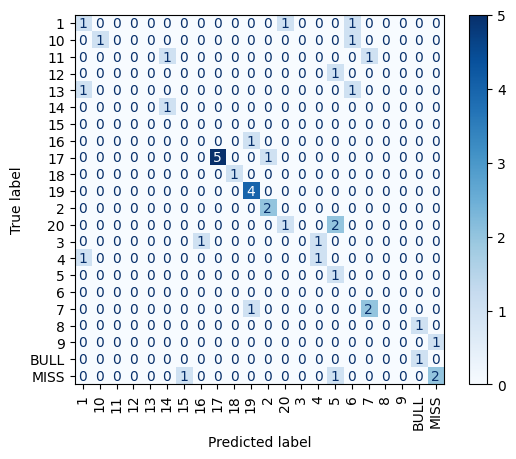

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=range(len(label_encoder.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues')

The accuracy with the weighted model is enhanced to 53,49% and therefore clearly better than the models before, but still no as good as you would want it to be for actual implementation as a live darts counter.

One reason we came across was, that we had trouble labelling the images with more than 1 darts. In the process of labelling the points, we always had the labelling tool show us all three camera views, each dart surrounded by its bounding box. The problem was, that we could not figure out how to always get the same dart marked with the same name, when there were multiple darts on the board. Therefore, we decided to train our model only using the images with one dart, which left us with only one third of our actual dataset.